In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

import numpy as np

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

2026-01-09 12:45:19.387566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767959119.405767  110290 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767959119.411414  110290 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767959119.424433  110290 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767959119.424448  110290 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767959119.424450  110290 computation_placer.cc:177] computation placer alr

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

/home/das214/SmartPix/SoftQuantize


In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [4]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"
dataset_base_dir = '/depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/'

NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

os.makedirs(dataset_train_dir, exist_ok=True)
os.makedirs(dataset_test_dir, exist_ok=True)
os.makedirs(tfrecords_dir_train, exist_ok=True)
os.makedirs(tfrecords_dir_val, exist_ok=True)

In [5]:
batch_size = 5000
val_batch_size = 5000
train_file_size = len(os.listdir(dataset_train_dir))
val_file_size = len(os.listdir(dataset_test_dir))

start_time = time.time()
validation_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_test_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = val_batch_size,
    # optimize_batch_size = True,
    file_count = val_file_size,
    to_standardize= False,
    select_contained = True,
    noise = [NOISE_MU,NOISE_SIGMA], #[mean, sigma]
    min_threshold = None,
    max_threshold = None,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,16,16), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, 
    files_from_end=True,

    tfrecords_dir = tfrecords_dir_val,
    use_time_stamps = [0,19],
    max_workers = 2
)

print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# training generator
start_time = time.time()
training_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_train_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = batch_size,
    # optimize_batch_size = True,
    file_count = train_file_size,
    to_standardize= False,
    select_contained = True,
    noise = [NOISE_MU,NOISE_SIGMA], #[mean, sigma]
    min_threshold = None,
    max_threshold = None,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,16,16), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, # True 

    tfrecords_dir = tfrecords_dir_train,
    use_time_stamps = [0,19],
    max_workers = 2
)
print("--- Training generator %s seconds ---" % (time.time() - start_time))

Processing Files...: 100%|██████████| 20/20 [00:09<00:00,  2.20it/s]


Directory /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val is removed...


Saving batches as TFRecords: 100%|██████████| 73/73 [00:15<00:00,  4.70it/s]


Metadata saved successfully ast /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json
--- Validation generator 26.098942518234253 seconds ---


Processing Files...: 100%|██████████| 80/80 [00:35<00:00,  2.27it/s]


Directory /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train is removed...


Saving batches as TFRecords: 100%|██████████| 289/289 [00:57<00:00,  5.05it/s]


Metadata saved successfully ast /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json
--- Training generator 93.29126787185669 seconds ---


In [6]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)

print("num train batches:", len(training_generator))
print("num val batches  :", len(validation_generator))

b = 0
X, y = training_generator[b]
X = X.numpy()
y = y.numpy()

print("X shape:", X.shape, "dtype:", X.dtype)   # expect (B, H, W, C) or similar
print("y shape:", y.shape, "dtype:", y.dtype)

Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json


Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json


num train batches: 289
num val batches  : 73
X shape: (5000, 16, 16, 2) dtype: float32
y shape: (5000, 4) dtype: float32


2026-01-09 12:47:24.624386: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


In [7]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

In [8]:
def create_quantizer_model(input_shape, initial_thresholds, threshold_offset):
    inp = layers.Input(shape=input_shape, name="raw_input")
    q_out = SoftQuantizeLayer(
        n_bits=2,
        initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
        threshold_offset=threshold_offset,
        initial_thresholds=initial_thresholds,
        trainable_levels=False,
        trainable_thresholds=False,
        initial_k=50.0,
        trainable_k=True,
        name="soft_quantizer_output"
    )(inp)
    return keras.Model(inputs=inp, outputs=q_out, name="quantizer")

quantizer_model = create_quantizer_model(
    input_shape=(16,16,2),
    initial_thresholds=[249.30, 667.66, 1659.27],
    threshold_offset=80.0
)

In [9]:
b = 0
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0]


In [10]:
from collections import Counter

def extract_patches(Q, patch_dim, stride=None, padding=None):
    """
    Q: (B,H,W,C) with discrete values (e.g. {0,1,2,3})
    patch_dim: (pH,pW)
    stride: (dY,dX) or None -> non-overlapping
    padding:
      - None: no padding (VALID)
      - "same": auto-pad so you cover the full image with the given stride
    """
    B, H, W, C = Q.shape
    pH, pW = patch_dim

    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride


    pad_top = pad_bot = pad_left = pad_right = 0

    if padding is None:
        pass
    elif padding == "same":
        # number of patch positions (like conv output size)
        nY = int(np.ceil(H / dY)) if dY > 0 else 1
        nX = int(np.ceil(W / dX)) if dX > 0 else 1

        H_pad = (nY - 1) * dY + pH
        W_pad = (nX - 1) * dX + pW

        padY = max(0, H_pad - H)
        padX = max(0, W_pad - W)

        pad_top  = padY // 2
        pad_bot  = padY - pad_top
        pad_left = padX // 2
        pad_right= padX - pad_left


    if any(v != 0 for v in (pad_top, pad_bot, pad_left, pad_right)):
        pad_width = ((0, 0), (pad_top, pad_bot), (pad_left, pad_right), (0, 0))
        Q = np.pad(Q, pad_width, mode="constant", constant_values=0)

    # update dims after padding
    B, H, W, C = Q.shape

    patches_ctr = Counter()
    for b in range(B):
        for c in range(C):
            for y in range(0, H - pH + 1, dY):
                for x in range(0, W - pW + 1, dX):
                    patch = Q[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    patches_ctr[key] += 1

    return patches_ctr


# Patch Analysis

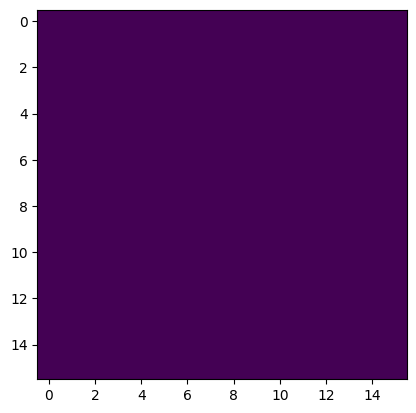

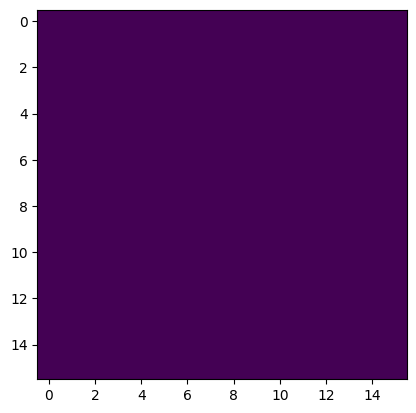

In [11]:
plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

In [12]:
patch_dim = (1, 1)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)

#patches: 2560000
#unique patches: 1


In [13]:
patch_dim = (4, 4)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)
print("first 5 patches:")

levels = set()
print("Top 10 patches:")
for pat, cnt in patches_ctr.most_common(10):
    print(pat, cnt)
    levels |= set(pat)
print("levels seen in patches:", levels)


#patches: 160000
#unique patches: 1
first 5 patches:
Top 10 patches:
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 160000
levels seen in patches: {0}


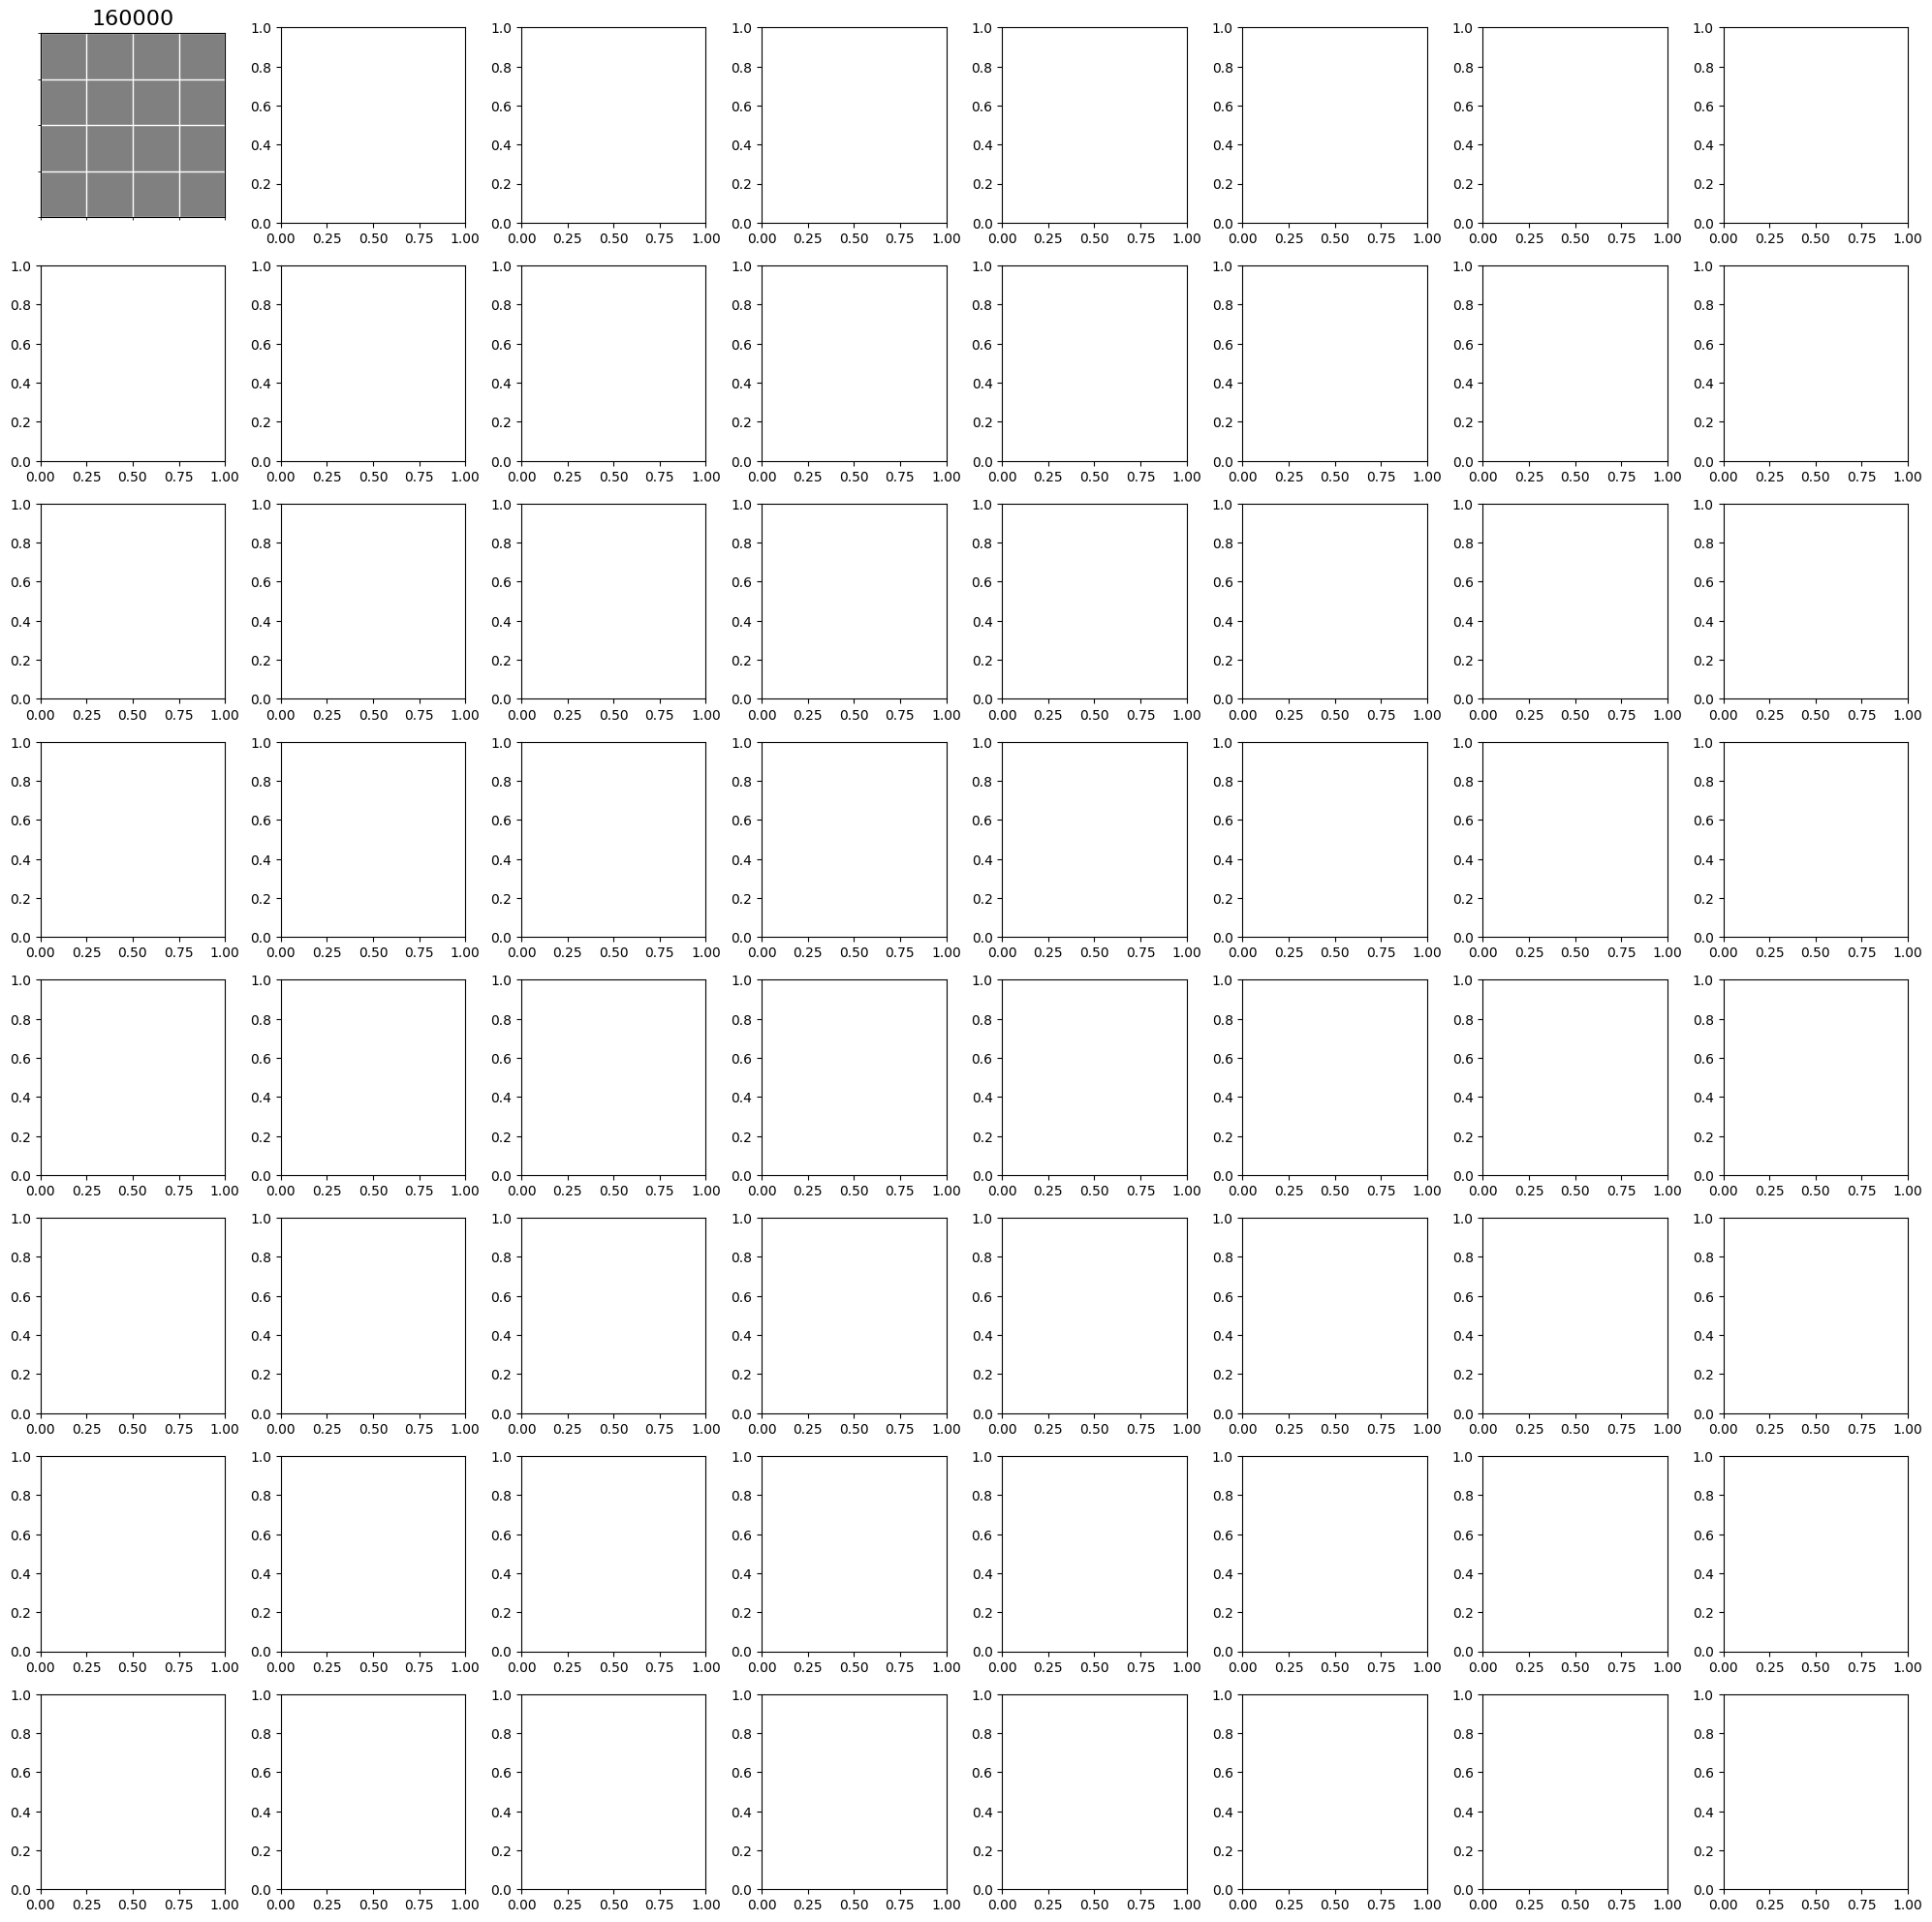

In [14]:
K = 64

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()


In [15]:
def estimate_bits_per_cell_from_topK(patches_ctr, pH, pW, K):
    """
    Simple top-K dictionary + ESC model:
      - encode symbol among (top-K patches + ESC) with ideal entropy H_sym (lower bound)
      - if ESC, transmit raw patch payload (pH*pW*bits_per_entry)

    Returns: (bits_per_cell, p_esc, H_sym_bits_per_patch)
    """
    total = sum(patches_ctr.values())  # total patch *occurrences*
    top = patches_ctr.most_common(K)
    top_counts = np.array([cnt for _, cnt in top], dtype=np.float64)

    levels = set()
    for pat, cnt in top:
        levels |= set(pat)
    n_levels = max(1, len(levels))
    bits_per_entry= np.ceil(np.log2(n_levels))
    
    p_top = top_counts / total
    p_esc = max(0.0, 1.0 - float(p_top.sum()))  # clamp for numerical safety

    # symbol distribution over K+1 symbols (K dictionary entries + ESC)
    p_sym = np.concatenate([p_top, np.array([p_esc])])
    p_nonzero = p_sym[p_sym > 0] # avoid log(0)
    H_sym = -np.sum(p_nonzero * np.log2(p_nonzero))  # bits per patch for symbol (ideal)

    raw_payload_bits = (pH * pW * bits_per_entry)  # sent only on ESC
    bits_per_patch = H_sym + p_esc * raw_payload_bits
    bits_per_cell = bits_per_patch / (pH * pW)

    return bits_per_cell, p_esc, H_sym

In [16]:
patch_dims = [(1,1), (2,2), (3,3), (4,4), (8,8)]
Ks = [8, 16, 32, 64, 128, 256, 512]

rows = []

print(f"{'patch':>9} {'K':>6} {'Keff':>6} {'bits/cell':>10} {'p_esc':>10} {'Hsym(b/patch)':>14} {'#patches':>10} {'#unique':>10}")

for (pH, pW) in patch_dims:
    patches_ctr = extract_patches(Q_int, (pH, pW), stride=None)  # non-overlapping
    npatch = sum(patches_ctr.values())
    nuniq  = len(patches_ctr)

    for K in Ks:
        K_eff = min(K, nuniq) if nuniq > 0 else 0

        bits_cell, p_esc, Hsym = estimate_bits_per_cell_from_topK(
            patches_ctr, pH, pW, K_eff
        )

        print(f"{str((pH,pW)):>9} {K:6d} {K_eff:6d} {bits_cell:10.4f} {p_esc:10.4f} {Hsym:14.4f} {npatch:10d} {nuniq:10d}")

        rows.append((pH, pW, K_eff, bits_cell, p_esc, Hsym, npatch, nuniq))


    patch      K   Keff  bits/cell      p_esc  Hsym(b/patch)   #patches    #unique
   (1, 1)      8      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)     16      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)     32      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)     64      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)    128      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)    256      1     0.0000     0.0000        -0.0000    2560000          1
   (1, 1)    512      1     0.0000     0.0000        -0.0000    2560000          1
   (2, 2)      8      1     0.0000     0.0000        -0.0000     640000          1
   (2, 2)     16      1     0.0000     0.0000        -0.0000     640000          1
   (2, 2)     32      1     0.0000     0.0000        -0.0000     640000          1
   (2, 2)     64      1     0.0000     0.0000        -0.0000     640000          1
   (

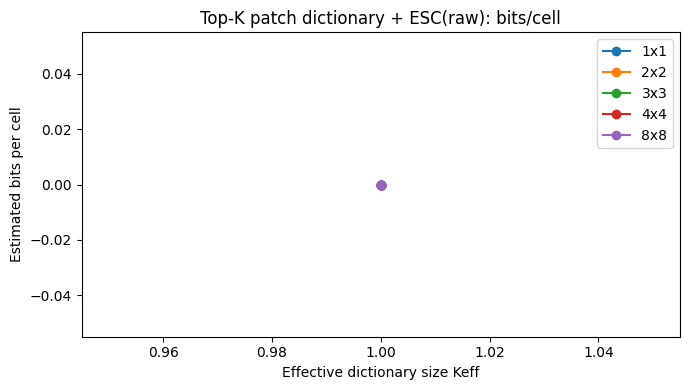

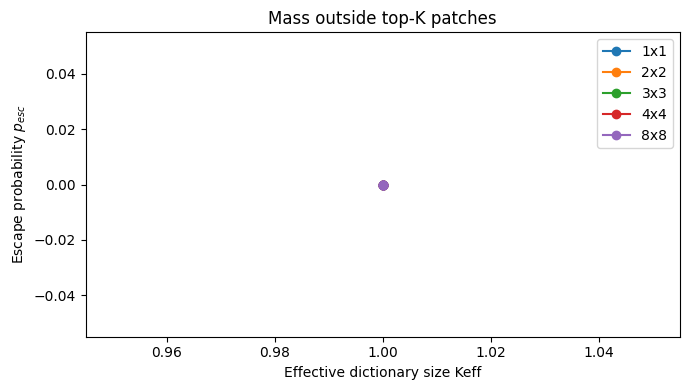

In [17]:
import pandas as pd

df = pd.DataFrame(rows, columns=["pH","pW","Keff","bits_cell","p_esc","Hsym","npatch","nuniq"])
df["patch"] = df["pH"].astype(str) + "x" + df["pW"].astype(str)

# bits/cell vs K (use original Ks on x-axis, but you stored Keff; easiest is plot vs Keff)
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["bits_cell"], marker="o", label=patch)
# plt.xscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Estimated bits per cell")
plt.title("Top-K patch dictionary + ESC(raw): bits/cell")
plt.legend()
plt.tight_layout()
plt.show()

# p_esc vs Keff
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["p_esc"], marker="o", label=patch)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Escape probability $p_{esc}$")
plt.title("Mass outside top-K patches")
plt.legend()
plt.tight_layout()
plt.show()

# Patch ID

In [18]:
from tqdm import tqdm
def extract_gbl_patch_ctr(data_gen, quantizer_model, patch_dim, stride=None, padding=None, max_batches=None):
    """
    Returns global Counter over ALL patches in the dataset (as seen through the generator).
    """
    global_ctr = Counter()
    n_seen = 0
    for (X, _) in tqdm(data_gen, desc="Building Global Patch-CTR"):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = quantizer_model(X_tf, training=False)
        Q_int = np.rint(Q_tf.numpy()).astype(np.uint8)

        batch_ctr = extract_patches(Q_int, patch_dim, stride=stride, padding=padding)
        global_ctr += batch_ctr

        n_seen += 1
        if max_batches is not None and n_seen >= int(max_batches):
            break

    return global_ctr

In [19]:
patch_dim = (2, 2)
unk_id=0
patches_ctr = extract_gbl_patch_ctr(
    training_generator, 
    quantizer_model,
    patch_dim=patch_dim,
    stride=None,
    padding="same",
    max_batches=None      # set e.g. 1 for a quick approximation
)

Building Global Patch-CTR: 100%|██████████| 289/289 [05:14<00:00,  1.09s/it]


In [20]:
def build_patch_dict_from_counter(patches_ctr, K, unk_id=0):
    """
    patch2id maps top-K patches to IDs 1..K. 0 reserved for UNK.
    """
    patch2id = {}
    K_eff = min(int(K), len(patches_ctr))  # guard if K > #unique
    for i, (pat, _) in enumerate(patches_ctr.most_common(K_eff), start=1):
        patch2id[pat] = i
    return patch2id, unk_id

In [21]:
K = 256
patch2id, unk_id = build_patch_dict_from_counter(patches_ctr, K, unk_id)
vocab_size = K + 1
print(patch2id)
print(unk_id)
print(vocab_size)

{(0, 0, 0, 0): 1}
0
257


In [22]:
def build_patch_LUT(patch2id, patch_dim, *, unk_id=0):
    """
    Returns tf.lookup.StaticHashTable mapping base-4 encoded patch key -> token id.

    base-4 key: key = sum_{j=0..K-1} patch[j] * 4^j   (K = pH*pW)
    """
    pH, pW = patch_dim
    K = pH * pW
    pow4 = (4 ** np.arange(K, dtype=np.int64))

    keys_np = np.array(
        [np.dot(np.asarray(pat, dtype=np.int64), pow4) for pat in patch2id.keys()],
        dtype=np.int64
    )
    vals_np = np.array(list(patch2id.values()), dtype=np.int64)

    init = tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(keys_np, dtype=tf.int64),
        values=tf.constant(vals_np, dtype=tf.int64),
        key_dtype=tf.int64,
        value_dtype=tf.int64,
    )
    table = tf.lookup.StaticHashTable(init, default_value=tf.constant(unk_id, tf.int64))
    return table, keys_np, vals_np

patch_LUT, dict_keys_np, dict_ids_np = build_patch_LUT(patch2id, patch_dim, unk_id=unk_id)
dict_ids_np = dict_ids_np.astype(np.int32)

In [23]:
def tokenize_batch(Q_int, patch_dim, patch_LUT,
                   stride=None, padding=None, *,
                   unk_id=0, return_coords=False,
                   # CHANGE: add NN-fallback inputs + metric/threshold
                   # REASON: allow replacing unk_id with closest dictionary patch id
                   dict_keys=None, dict_ids=None,
                   nn_metric="l1", max_dist=None):
    """
    dict_keys: (M,) int64 base-4 encoded patch keys for ALL dictionary entries
    dict_ids : (M,) int32 token ids aligned with dict_keys
    nn_metric: "l1" or "hamming"
    max_dist: optional int; if nearest distance > max_dist, keep unk_id
    """

    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    Q = tf.convert_to_tensor(Q_int)
    B = tf.shape(Q)[0]
    H = tf.shape(Q)[1]
    W = tf.shape(Q)[2]
    C = tf.shape(Q)[3]

    # (B,H,W,C) -> (B,C,H,W,1) -> (B*C,H,W,1)
    Q_bc = tf.transpose(Q, [0, 3, 1, 2])
    Q_bc = tf.reshape(Q_bc, [-1, H, W, 1])

    padding_tf = "VALID" if padding is None else str(padding).upper()

    patches = tf.image.extract_patches(
        images=Q_bc,
        sizes=[1, pH, pW, 1],
        strides=[1, dY, dX, 1],
        rates=[1, 1, 1, 1],
        padding=padding_tf,
    )  # (B*C, out_h, out_w, K)

    K = pH * pW
    powv = tf.pow(tf.constant(4, tf.int64), tf.range(K, dtype=tf.int64))  # (K,)
    keys = tf.reduce_sum(tf.cast(patches, tf.int64) * powv, axis=-1)      # (B*C, out_h, out_w)

    ids = patch_LUT.lookup(keys)  # int64
    out_h = tf.shape(ids)[1]
    out_w = tf.shape(ids)[2]

    # CHANGE: nearest-neighbor fallback for unknown keys
    # REASON: replace unk_id by closest dictionary entry in patch space
    if dict_keys is not None and dict_ids is not None:
        unk_id_i64 = tf.cast(unk_id, ids.dtype)
        unk_mask = tf.equal(ids, unk_id_i64)

        if tf.reduce_any(unk_mask):
            # flatten (B*C*out_h*out_w)
            patches_flat = tf.reshape(patches, [-1, K])          # dtype like Q (uint8/int)
            ids_flat     = tf.reshape(ids, [-1])
            unk_mask_f   = tf.reshape(unk_mask, [-1])

            unk_patches = tf.boolean_mask(patches_flat, unk_mask_f)  # (N,K)
            unk_patches = tf.cast(unk_patches, tf.int16)

            dk = tf.convert_to_tensor(dict_keys, tf.int64)
            di = tf.convert_to_tensor(dict_ids, tf.int32)

            # drop any entry that maps to unk_id (just in case)
            keep = tf.not_equal(di, tf.cast(unk_id, tf.int32))
            dk = tf.boolean_mask(dk, keep)
            di = tf.boolean_mask(di, keep)

            # decode base-4 key -> patch digits (M,K)
            dict_patches = tf.math.floordiv(dk[:, None], powv[None, :]) % 4
            dict_patches = tf.cast(dict_patches, tf.int16)

            # distances (N,M)
            if str(nn_metric).lower() == "hamming":
                dist = tf.reduce_sum(
                    tf.cast(tf.not_equal(unk_patches[:, None, :], dict_patches[None, :, :]), tf.int32),
                    axis=-1
                )
            else:  # "l1"
                dist = tf.reduce_sum(tf.abs(unk_patches[:, None, :] - dict_patches[None, :, :]), axis=-1)

            nn_idx = tf.argmin(dist, axis=1, output_type=tf.int32)     # (N,)
            nn_ids = tf.gather(di, nn_idx)                             # (N,)
            min_d  = tf.reduce_min(dist, axis=1)                       # (N,)

            if max_dist is not None:
                max_dist_i = tf.cast(max_dist, min_d.dtype)
                nn_ids = tf.where(min_d <= max_dist_i, nn_ids, tf.cast(unk_id, tf.int32))

            pos = tf.where(unk_mask_f)[:, 0]                           # (N,)
            ids_flat = tf.tensor_scatter_nd_update(
                ids_flat,
                tf.expand_dims(pos, 1),
                tf.cast(nn_ids, ids_flat.dtype)
            )
            ids = tf.reshape(ids_flat, tf.shape(ids))

    ids = tf.reshape(ids, [B, C, out_h, out_w])        # (B,C,oy,ox)
    tokens = tf.reshape(ids, [B, C * out_h * out_w])   # (B,L)
    tokens = tf.cast(tokens, tf.int32)

    if not return_coords:
        return tokens

    if padding_tf == "VALID":
        y0 = tf.range(out_h, dtype=tf.int32) * dY
        x0 = tf.range(out_w, dtype=tf.int32) * dX
    else:
        out_h_same = (H + dY - 1) // dY
        out_w_same = (W + dX - 1) // dX

        padY = tf.maximum((out_h_same - 1) * dY + pH - H, 0)
        padX = tf.maximum((out_w_same - 1) * dX + pW - W, 0)
        pad_top  = padY // 2
        pad_left = padX // 2

        y0 = tf.range(out_h, dtype=tf.int32) * dY - pad_top
        x0 = tf.range(out_w, dtype=tf.int32) * dX - pad_left

    yy, xx = tf.meshgrid(y0, x0, indexing="ij")  # (oy,ox)
    yx = tf.stack([tf.reshape(yy, [-1]), tf.reshape(xx, [-1])], axis=1)  # (oy*ox,2)

    Lsp = tf.shape(yx)[0]
    ccol = tf.repeat(tf.range(C), Lsp)
    yx_rep = tf.tile(yx, [C, 1])
    coords = tf.concat([tf.expand_dims(ccol, 1), yx_rep], axis=1)  # (L,3) = (c,y,x)

    return tokens, coords


In [24]:
patch_LUT

In [25]:
def decode_tokens_to_patches(tokens,
                             patch_dim,
                             *,
                             dict_keys,   # (M,) int64 base-4 keys
                             dict_ids,    # (M,) int32/int64 token ids aligned with dict_keys
                            ):
    """
    Decode token IDs back to patch digits.

    Args
    ----
    tokens:    (B,L) int32/int64
    patch_dim: (pH,pW)
    dict_keys: (M,) int64 base-4 keys for dictionary entries
    dict_ids:  (M,) token ids corresponding to dict_keys

    Returns
    -------
    patches: (B,L,pH,pW) int16
    """

    pH, pW = patch_dim
    K = pH * pW

    tokens = tf.convert_to_tensor(tokens)
    tokens_i64 = tf.cast(tokens, tf.int64)

    dk = tf.convert_to_tensor(np.asarray(dict_keys, dtype=np.int64), tf.int64)
    di = tf.convert_to_tensor(np.asarray(dict_ids,  dtype=np.int64), tf.int64)

    # Build id -> key LUT (default key=0; we'll override UNK separately)
    init = tf.lookup.KeyValueTensorInitializer(
        keys=tf.cast(di, tf.int64),
        values=tf.cast(dk, tf.int64),
        key_dtype=tf.int64,
        value_dtype=tf.int64,
    )
    id2key = tf.lookup.StaticHashTable(init, default_value=tf.constant(0, tf.int64))

    keys = id2key.lookup(tokens_i64)  # (B,L) int64

    # Decode base-4 digits in the same convention as your encoder:
    # key = sum_j digit[j] * 4^j  => digit[j] = floor(key / 4^j) % 4
    powv = tf.pow(tf.constant(4, tf.int64), tf.range(K, dtype=tf.int64))  # (K,)
    digits = (keys[..., None] // powv[None, None, :]) % 4                # (B,L,K)
    digits = tf.cast(digits, tf.int16)

    patches = tf.reshape(digits, [tf.shape(tokens_i64)[0], tf.shape(tokens_i64)[1], pH, pW])
    return patches


In [26]:
class TokenizedSequence(keras.utils.Sequence):
    def __init__(self, base_seq, quantizer_model, patch_dim, patch_LUT,
                 dict_keys_np, dict_ids_np, tfrecords_dir=None,
                 unk_id=0, stride=None, padding=None,
                 patches_out_type=tf.int16, y_out_type=tf.float32,
                 compression=None,  # None | "GZIP" | "ZLIB"
                 write_on_init=True):
        self.base = base_seq
        self.qm = quantizer_model
        self.patch_dim = patch_dim
        self.patch_LUT = patch_LUT
        self.unk_id = unk_id
        self.stride = stride
        self.padding = padding

        if tfrecords_dir is None:
            tfrecords_dir = os.path.join(self.base.tfrecords_dir, "patches")
        self.tfrecords_dir = tfrecords_dir

        self.dict_keys = np.asarray(dict_keys_np, dtype=np.int64)
        self.dict_ids  = np.asarray(dict_ids_np,  dtype=np.int32)

        self.patches_out_type = patches_out_type
        self.y_out_type = y_out_type
        self.compression = compression

        if write_on_init:
            self.write_tfrecords(self.tfrecords_dir, compression=self.compression)

        self.tfrecord_files = np.sort(np.array(
            tf.io.gfile.glob(os.path.join(self.tfrecords_dir, "*.tfrecord"))
        ))

    def __len__(self):
        return len(self.base)

    def _tokenize(self, Q_int):
        tokens = tokenize_batch(
            Q_int,
            self.patch_dim,
            self.patch_LUT,
            stride=self.stride,
            padding=self.padding,
            unk_id=self.unk_id,
            dict_keys=self.dict_keys,
            dict_ids=self.dict_ids.astype(np.int32),
            nn_metric="l1",
            max_dist=None
        )
        return tokens

    def _decode_tokens_to_patches(self, tokens):
        patches = decode_tokens_to_patches(
            tokens,
            patch_dim=self.patch_dim,
            dict_keys=self.dict_keys,
            dict_ids=self.dict_ids,
        )
        return patches

    def __getitem__(self, idx):
        if self.tfrecord_files is None or len(self.tfrecord_files) == 0:
            raise ValueError(f"No TFRecord files found in: {self.tfrecords_dir}")

        path = self.tfrecord_files[idx]
        ds = tf.data.TFRecordDataset(path, compression_type=(self.compression or ""))
        ds = ds.map(self._parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)

        # take the single record
        it = iter(ds)
        try:
            patches, y = next(it)
        except StopIteration:
            raise ValueError(f"Empty TFRecord file: {path}")

        return patches, y

    @staticmethod
    def _bytes_feature(value):
        if isinstance(value, type(tf.constant(0))):
            value = value.numpy()
        return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

    def _serialize_example(self, patches, y, patches_dtype=tf.int16, y_dtype=tf.float32):
        patches = tf.cast(patches, patches_dtype)
        y = tf.cast(y, y_dtype)

        feat = {
            "patches": self._bytes_feature(tf.io.serialize_tensor(patches)),
            "y":       self._bytes_feature(tf.io.serialize_tensor(y)),
        }
        ex = tf.train.Example(features=tf.train.Features(feature=feat))
        return ex.SerializeToString()

    def get_patches(self, X, y):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = self.qm(X_tf, training=False)
        Q_int = tf.cast(tf.round(Q_tf), tf.int64)

        tokens = self._tokenize(Q_int)                     # (B,L)
        patches = self._decode_tokens_to_patches(tokens)   # (B,L,pH,pW) (or similar)

        return patches

    def write_tfrecords(
        self,
        tfrecords_dir: str,
        *,
        max_batches: int = None,
        prefix: str = "batch",
        compression: str = None,     # None | "GZIP" | "ZLIB"
        patches_dtype=tf.int16,
        y_dtype=tf.float32,
        verbose: int = 1,
    ):
        os.makedirs(tfrecords_dir, exist_ok=True)

        n_total = len(self.base)
        n_write = n_total if max_batches is None else min(int(max_batches), n_total)

        options = None
        if compression is not None:
            options = tf.io.TFRecordOptions(compression_type=compression)

        it = range(n_write)
        if verbose:
            print(f"[TokenizedSequence] Writing {n_write}/{n_total} batches -> {tfrecords_dir}")
            it = tqdm(it, desc="[TokenizedSequence] Writing TFRecords", unit="batch")
        
        for i in it:
            X, y = self.base[i]  # X: (B,H,W,C) float32, y: (B,...) numpy
            patches = self.get_patches(X, y)   # (B,L,pH,pW) (or similar)

            patches_tf = tf.convert_to_tensor(patches)
            y_tf = tf.convert_to_tensor(y)

            out_path = os.path.join(tfrecords_dir, f"{prefix}_{i:06d}.tfrecord")
            rec = self._serialize_example(patches_tf, y_tf, patches_dtype, y_dtype)

            with tf.io.TFRecordWriter(out_path, options=options) as w:
                w.write(rec)

        if verbose:
            print("[TokenizedSequence] Done.")

    def _parse_tfrecord_fn(self, example):
        feature_description = {
            "patches": tf.io.FixedLenFeature([], tf.string),
            "y":       tf.io.FixedLenFeature([], tf.string),
        }
        ex = tf.io.parse_single_example(example, feature_description)

        patches = tf.io.parse_tensor(ex["patches"], out_type=self.patches_out_type)
        y       = tf.io.parse_tensor(ex["y"],       out_type=self.y_out_type)

        return patches, y

In [27]:
# usage
train_tok = TokenizedSequence(
    training_generator, quantizer_model, patch_dim, patch_LUT,
    dict_keys_np, dict_ids_np,
    unk_id=unk_id, stride=None, padding="same",
    patches_out_type=tf.int16, y_out_type=tf.float32,
    compression=None,          # or "GZIP"
    write_on_init=True
)

val_tok = TokenizedSequence(
    validation_generator, quantizer_model, patch_dim, patch_LUT,
    dict_keys_np, dict_ids_np,
    unk_id=unk_id, stride=None, padding="same",
    patches_out_type=tf.int16, y_out_type=tf.float32,
    compression=None,
    write_on_init=True
)

t0, y0 = train_tok[0]
print("patches:", t0.shape, t0.dtype, "y:", y0.shape, y0.dtype)

seq_len = t0.shape[1]
print("seq_len:", seq_len)

[TokenizedSequence] Writing 289/289 batches -> /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/patches


[TokenizedSequence] Writing TFRecords: 100%|██████████| 289/289 [00:34<00:00,  8.35batch/s]


[TokenizedSequence] Done.
[TokenizedSequence] Writing 73/73 batches -> /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/patches


[TokenizedSequence] Writing TFRecords: 100%|██████████| 73/73 [00:08<00:00,  8.55batch/s]


[TokenizedSequence] Done.
patches: (5000, 128, 2, 2) <dtype: 'int16'> y: (5000, 4) <dtype: 'float32'>
seq_len: 128


In [28]:
def create_patch_LUT_model(
    seq_len, patch_dim,
    d_model=64, n_heads=4, ff=128, n_layers=3,
    n_outputs=14, dropout=0.1
    ):
    
    pH, pW = patch_dim

    # INPUT LAYER
    patches_in = layers.Input(shape=(seq_len, pH, pW), dtype=tf.float32, name="patch_patterns") #(B, Seq_Len, pH, pW)
    patches_emb = layers.Reshape((seq_len, pH * pW))(patches_in) # (B, L, pH, pW) -> (B, L, pH * pW)
    patches_emb = layers.Dense(d_model, name="pattern_projection")(patches_emb)
    
    pos_ids = tf.range(seq_len)[None, :]
    pos_emb = tf.keras.layers.Embedding(seq_len, d_model, name="pos_emb")(pos_ids)
    x = patches_emb + pos_emb

    for i in range(n_layers):
        # Self-attn block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads)(x, x)
        x = tf.keras.layers.Add()([x0, x])

        # FFN block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.Dense(ff, activation="gelu")(x)
        x = tf.keras.layers.Dense(d_model)(x)
        x = tf.keras.layers.Add()([x0, x])

    x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Head
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)

    out = tf.keras.layers.Dense(n_outputs, name="head")(x)

    return tf.keras.Model(patches_in, out)

lut_model = create_patch_LUT_model(
    seq_len=seq_len,
    patch_dim=patch_dim,
    d_model=32,    # smaller
    n_heads=4,
    ff=64,
    n_layers=3,
    n_outputs=14,
)
lut_model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

lut_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patch_patterns      │ (None, 128, 2, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 128, 4)    │          0 │ patch_patterns[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pattern_projection  │ (None, 128, 32)   │        160 │ reshape[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 32)   │          0 │ pattern_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 32)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 32)   │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 32)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 32)   │          0 │ add_2[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 32)   │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128, 32)   │          0 │ add_3[0][0],      │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_4[0][0]     

 Total params: 41,358 (161.55 KB)

 Trainable params: 41,358 (161.55 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
xb, yb = train_tok[0]
pred = lut_model(xb[:8], training=False)

print("pred:", pred.shape, pred.dtype)
print("y   :", yb[:8].shape, yb[:8].dtype)

loss_val = custom_loss(tf.convert_to_tensor(yb[:8]), pred)
print("loss(sample batch):", float(tf.reduce_mean(loss_val)))


pred: (8, 14) <dtype: 'float32'>
y   : (8, 4) <dtype: 'float32'>


I0000 00:00:1767959616.775571  110290 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5649b5e6e280


loss(sample batch): 165.7861328125


In [30]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_LUT_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, "weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5")

In [31]:
# 9f5e5c2c : 1000 epochs
print(checkpoint_filepath)
print(fingerprint)

./trained_LUT_models/model-35b05435-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5
35b05435


In [32]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [ ]:
history = lut_model.fit(
    train_tok,
    validation_data=val_tok,
    callbacks=[mcp, csv_logger, es],
    epochs=1000,
    verbose=1
)

Epoch 1/1000


/depot/cms/conda_envs/das214/pquant-gpu-env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1767959625.283073  111173 service.cc:152] XLA service 0x7f61c812e740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767959625.283126  111173 service.cc:160]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB MIG 7g.40gb, Compute Capability 8.0
2026-01-09 12:53:45.577828: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767959627.323203  111173 cuda_dnn.cc:529] Loaded cuDNN version 90501
2026-01-09 12:53:5

  2/289 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 103616.3281   

I0000 00:00:1767959642.763468  111173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 21/289 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 103616.3203

...

181/289 ━━━━━━━━━━━━━━━━━━━━ 27s 255ms/step - loss: 103242.5625

2026-01-09 12:54:53.208530: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1988', 4 bytes spill stores, 4 bytes spill loads

2026-01-09 12:54:53.547955: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2016', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 12:54:53.681992: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8776_0', 240 bytes spill stores, 240 bytes spill loads

2026-01-09 12:54:53.685492: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8689', 88 bytes spill stores, 88 bytes spill loads

2026-01-09 12:54:53.742173: I external

289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 103305.1719

2026-01-09 12:55:22.955919: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1006', 4 bytes spill stores, 4 bytes spill loads

2026-01-09 12:55:23.218517: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1034', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 12:55:23.237894: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1006', 8 bytes spill stores, 8 bytes spill loads

2026-01-09 12:55:23.514203: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1013', 584 bytes spill stores, 428 bytes spill loads

2026-01-09 12:55:27.007087: I external/loc

289/289 ━━━━━━━━━━━━━━━━━━━━ 112s 299ms/step - loss: 103305.6719 - val_loss: 102916.4844
Epoch 2/1000
289/289 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 103533.8750 - val_loss: 102916.4844
Epoch 3/1000
232/289 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 103580.2734

In [ ]:
def plot_keras_history(history):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h['loss'], 'o-', label='Train Loss', markersize=3)
    plt.plot(epochs, h['val_loss'], 'o-', label='Val Loss', markersize=3)
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Log-Loss Plot (Crucial for your 100k loss values)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h['loss'], 'o-', label='Train Loss', markersize=3)
    plt.plot(epochs, h['val_loss'], 'o-', label='Val Loss', markersize=3)
    plt.yscale('log')
    plt.title('Loss vs. Epochs (Log Scale)')
    plt.xlabel('Epochs')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call the function
plot_keras_history(history)